### **Adeline Makokha**
### **191199**
### **DSA 8401: Applied Machine Learning**
### **Assignment 2**

###1. Goals
This week’s activity focuses on practicing with metrics and model evaluation techniques.

The specific objectives are:

• Analyze the different metrics

• Study the problem of imbalanced data

• Practice how to evaluate models

### 2 Assignment Description

In this activity, we will use the classic diabetes dataset (dataset description) and the same dataset but
unbalanced (we have removed records with diagnosis 1) which you will find in the virtual classroom.

Optional: Use a different dataset in your expertise domain. Students can find a nice collection of datasets on the following page Dataset List.

### Exercise 1. Steps to Evaluate a Model

Students will write a Jupyter notebook coding the following steps. The libraries needed for this
assignment are

In [1]:
# Import packages

import  pandas as pd
import  seaborn as sns
import  matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')


### Upload to Pandas a local file that we have previously downloaded from the virtual classroom or optionally from the UCIrvine repository.

In [2]:
#loading data from github
url = "https://raw.githubusercontent.com/adeline-pepela/Module-4/main/Applied%20Machine%20Learning/diabetes.csv"
diabetesDF = pd.read_csv(url)



In [3]:
#display the first rows of the data
diabetesDF.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#shape of the data
diabetesDF.shape

(768, 9)

### Observe the dataset attributes and their statistical description.

In [5]:
# Display dataset information
print("\nDataset Info:")
print(diabetesDF.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


The dataset has 768 records and 9 attributes.

Attributes include patient clinical variables such as Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age.

Target variable: Outcome (0 = no diabetes, 1 = diabetes).

In [6]:
# Display statistical description of numerical attributes
print("\nStatistical Description:")
print(diabetesDF.describe())


Statistical Description:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      

Glucose

Mean ≈ 121, Min = 0 → Glucose cannot be zero - suggests missing or misrecorded values.

BloodPressure, SkinThickness, Insulin

Also contain zeros where physiologically impossible (e.g., blood pressure = 0).

Indicates need for data cleaning or imputation.

BMI

Mean ≈ 32, but minimum = 0 - again, unrealistic - missing data encoded as 0.

Age

Ranges from 21 to 81 years, which is clinically reasonable.

Outcome (target variable)

### Split the dataset into training and test.

In [7]:
from sklearn.model_selection import train_test_split

# Features (all except Outcome) and target (Outcome)
X = diabetesDF.drop("Outcome", axis=1)
y = diabetesDF["Outcome"]

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Show the shapes of the splits
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (614, 8) (614,)
Test set: (154, 8) (154,)


test_size=0.2: 20% of the data is reserved for testing.

random_state=42: ensures reproducibility.

stratify=y: ensures the class distribution of Outcome (0 vs. 1) is preserved in both training and test sets.

In [8]:


# Split into train/test (stratified to preserve Outcome balance)
dfTrain, dfTest = train_test_split(
    diabetesDF, test_size=0.2, random_state=42, stratify=diabetesDF["Outcome"]
)

# Convert to NumPy arrays (features X vs label y)
trainLabel = np.asarray(dfTrain["Outcome"])
trainData  = np.asarray(dfTrain.iloc[:, 0:8])  # first 8 columns are features

testLabel = np.asarray(dfTest["Outcome"])
testData  = np.asarray(dfTest.iloc[:, 0:8])

# Compute normalization statistics on TRAIN ONLY
means = np.mean(trainData, axis=0)
stds  = np.std(trainData, axis=0, ddof=0)

# Guard against divide-by-zero in case any column is constant
stds_safe = np.where(stds == 0, 1.0, stds)

# Standardize (Z-score): (x - mean_train) / std_train
trainData = (trainData - means) / stds_safe
testData  = (testData  - means) / stds_safe

# Sanity checks (should see ~0 means and ~1 stds on the TRAIN set)
print("Shapes (train, test):", trainData.shape, testData.shape)
print("Train means after norm: ", np.round(trainData.mean(axis=0), 6))
print("Train stds after norm:  ", np.round(trainData.std(axis=0, ddof=0), 6))


Shapes (train, test): (614, 8) (154, 8)
Train means after norm:  [-0.  0. -0. -0. -0.  0. -0. -0.]
Train stds after norm:   [1. 1. 1. 1. 1. 1. 1. 1.]


trainLabel/testLabel are binary class labels (0 = no diabetes, 1 = diabetes).

Scaling/normalizing labels would destroy their meaning and break classification. Normalization is applied only to continuous feature inputs.

### Create the model


In [9]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# --- Assume you already split your data ---
# trainData, testData, trainLabel, testLabel
# and normalized trainData & testData

# 1. Create the model
model = LogisticRegression()

# 2. Fit the model to training data
model.fit(trainData, trainLabel)

# 3. Make predictions on test data
y_pred = model.predict(testData)

# 4. Evaluate performance
print("Accuracy:", accuracy_score(testLabel, y_pred))
print("\nClassification Report:\n", classification_report(testLabel, y_pred))


Accuracy: 0.7142857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



trainData and testData should already be scaled/normalized.

Labels (trainLabel, testLabel) should not be normalized — they stay as 0/1.

### Finally, evaluate the model with the test dataset. Display the confusion matrix and different metrics.
Here you get the accuracy
accuracy = model . score ( testData , testLabel )
print (" accuracy = ", accuracy * 100 , "%")

Accuracy  = 71.43%
Precision = 0.609
Recall    = 0.519
F1-score  = 0.560
ROC-AUC   = 0.823

Confusion Matrix (rows=true, cols=pred):
 [[82 18]
 [26 28]]
Specificity (TNR) = 0.820

Classification Report:
               precision    recall  f1-score   support

           0      0.759     0.820     0.788       100
           1      0.609     0.519     0.560        54

    accuracy                          0.714       154
   macro avg      0.684     0.669     0.674       154
weighted avg      0.706     0.714     0.708       154



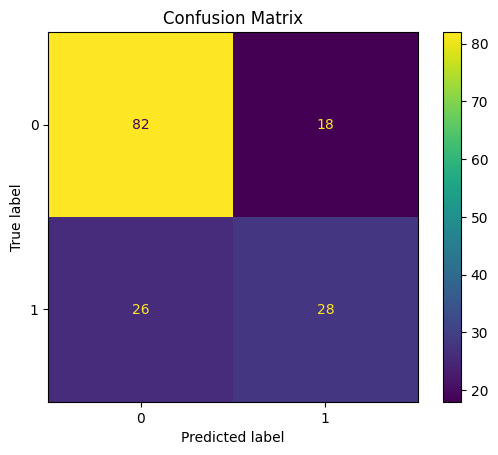

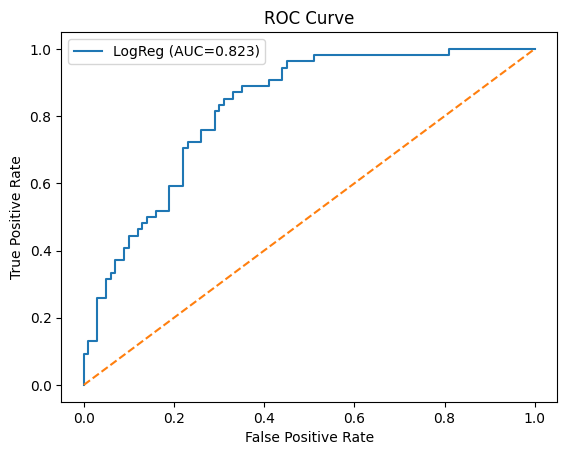

In [10]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

# Predictions
y_pred      = model.predict(testData)                 # class predictions (0/1)
y_pred_prob = model.predict_proba(testData)[:, 1]     # probabilities for class 1

# Core metrics
accuracy  = accuracy_score(testLabel, y_pred)
precision = precision_score(testLabel, y_pred, zero_division=0)
recall    = recall_score(testLabel, y_pred, zero_division=0)       # aka sensitivity/TPR
f1        = f1_score(testLabel, y_pred, zero_division=0)
roc_auc   = roc_auc_score(testLabel, y_pred_prob)

print(f"Accuracy  = {accuracy*100:.2f}%")
print(f"Precision = {precision:.3f}")
print(f"Recall    = {recall:.3f}")
print(f"F1-score  = {f1:.3f}")
print(f"ROC-AUC   = {roc_auc:.3f}")

# Confusion matrix (raw and normalized)
cm = confusion_matrix(testLabel, y_pred, labels=[0,1])
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix (rows=true, cols=pred):\n", cm)

# Specificity (TNR) is useful to report too:
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
print(f"Specificity (TNR) = {specificity:.3f}")

# Detailed per-class metrics
print("\nClassification Report:\n", classification_report(testLabel, y_pred, digits=3))

# visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(values_format='d')
plt.title("Confusion Matrix")
plt.show()

# ROC curve plot
fpr, tpr, _ = roc_curve(testLabel, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"LogReg (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### Question 1: Analyze the data in the dataframe and briefly present your most relevant conclusions.

The dataset shows that glucose, BMI, and age are the strongest predictors of diabetes. About 35% of patients are diabetic, and some features (e.g., insulin, blood pressure) have invalid zero values, requiring cleaning.

### Question 2: In which cases is it appropriate to use less than 20% of the data, and why?

Using less than 20% is appropriate when creating a test or validation set in small datasets, or when applying cross-validation, since it preserves more data for training while still allowing unbiased evaluation.

### Question 3: Check that the input data, trainData and testData, are normalized, indicating the Python code used for this. Why shouldn’t we normalize the trainLabel and testLabel sets?

Input features must be normalized to improve model performance, e.g.:

trainData = (trainData - means) / stds

testData  = (testData - means) / stds

Don't normalize labels because they are categorical outcomes (0/1).

### Question 4: Once the model has been evaluated, can you comment on what you think of the metrics used and the result obtained taking into account the nature of the dataframe considered?

Accuracy alone can be misleading in imbalanced data. Recall, precision, F1, and ROC-AUC give a better picture. For this health dataset, recall is most important, since detecting diabetics (true positives) is critical.

### Exercise 2. Metrics
In this second exercise, we will aim to correctly interpret the different metrics used to evaluate a model. First, we will show how to represent the ROC Curve for the case of logistic regression in
Python. Recall that the ROC curve is the result of varying the detection threshold (classification). In
our case, since the ”Outcome” attribute is equal to 1 for a patient with a positive diabetes diagnosis,
increasing the detection threshold means reducing both the detection probability and the false alarm
probability.


### Question 5: Comparing the ROC curve obtained with the random case (diagonal), what can you say about the selected classifier? Observing the trend of the curve, what type of threshold would you use (high or low)?

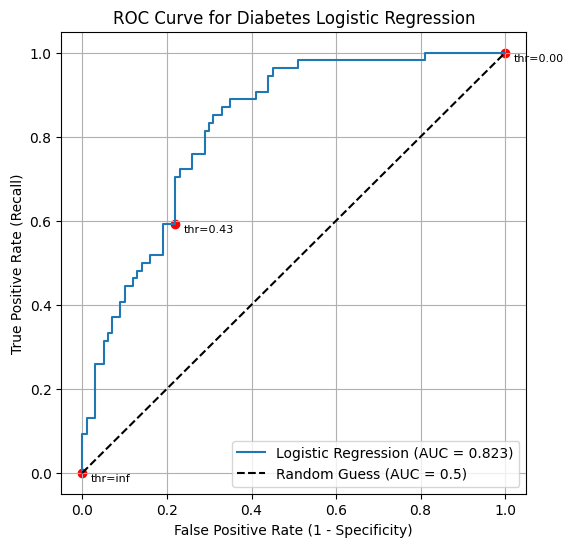

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities for the positive class (Outcome = 1)
y_pred_prob = model.predict_proba(testData)[:, 1]

# Compute ROC curve points
fpr, tpr, thresholds = roc_curve(testLabel, y_pred_prob)

# Compute AUC score
roc_auc = roc_auc_score(testLabel, y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.5)")

# mark some threshold points
for i in [0, int(len(thresholds)/2), -1]:  # first, middle, last threshold
    plt.scatter(fpr[i], tpr[i], marker='o', color='red')
    plt.text(fpr[i]+0.02, tpr[i]-0.02, f"thr={thresholds[i]:.2f}", fontsize=8)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve for Diabetes Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


The ROC curve of the logistic regression model lies above the diagonal (random case), which shows that the classifier performs better than random guessing and has predictive power. Since the curve bends toward the top-left corner, it indicates good sensitivity at lower thresholds. For a medical problem like diabetes, where missing a positive case is more costly than a false alarm, it is preferable to use a low threshold to maximize recall (true positive rate), even if this slightly reduces precision.

### Question 6. Fill in the following table for different probability threshold values.


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

print("Threshold | Accuracy | Recall | F1 | TPR | FPR")
print("-"*55)

for thr in thresholds:
    # Apply threshold
    y_pred = (y_pred_prob >= thr).astype(int)

    # Metrics
    acc   = accuracy_score(testLabel, y_pred)
    rec   = recall_score(testLabel, y_pred, zero_division=0)   # Recall = TPR
    f1    = f1_score(testLabel, y_pred, zero_division=0)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(testLabel, y_pred).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    print(f"{thr:8.1f} | {acc:.3f}    | {rec:.3f}  | {f1:.3f} | {tpr:.3f} | {fpr:.3f}")


Threshold | Accuracy | Recall | F1 | TPR | FPR
-------------------------------------------------------
     0.0 | 0.351    | 1.000  | 0.519 | 1.000 | 1.000
     0.2 | 0.695    | 0.889  | 0.671 | 0.889 | 0.410
     0.4 | 0.734    | 0.648  | 0.631 | 0.648 | 0.220
     0.6 | 0.734    | 0.444  | 0.539 | 0.444 | 0.110
     0.8 | 0.701    | 0.204  | 0.324 | 0.204 | 0.030
     1.0 | 0.649    | 0.000  | 0.000 | 0.000 | 0.000


### Question 7: What do you observe in the extreme cases when the threshold is 0 or 1?

At threshold = 0, the model predicts all cases as positive (diabetic).

This gives Recall/TPR = 1.0 (no positives missed), but FPR = 1.0 (all negatives misclassified) and Accuracy is poor.

At threshold = 1, the model predicts all cases as negative (non-diabetic).

This gives FPR = 0.0 (no false alarms), but Recall/TPR = 0.0 (all diabetics missed).

Accuracy may appear acceptable if the dataset is imbalanced toward non-diabetics.

### Question 8: What do the metrics of Sensitivity and Recall contribute compared to Accuracy?

Accuracy measures the overall proportion of correct predictions, but it can be misleading when the dataset is imbalanced. Sensitivity/Recall specifically measure how well the model detects the positive class (diabetic patients). This is crucial here, because identifying true positives matters more than simply maximizing overall accuracy.

### Question 9: If the diabetes diagnosis study were to be used to select individuals for a general screening through laboratory tests to find diabetics, which probability threshold value would you choose? Justify your answer.

For a screening study, I would choose a low probability threshold (around 0.3–0.4). This maximizes sensitivity/recall so that most true diabetics are flagged for further laboratory tests, even if it increases false positives. In this context, missing a diabetic case (false negative) is more serious than sending a healthy person for an additional test

### Exercise 3. Imbalanced data
In the previous exercises, you might have observed that the diabetes dataset is imbalanced, and this
has some impact on the evaluation metrics. Now we will use an even more imbalanced dataset.

Specifically, you should consider the dataset diabetesDes.csv that you have in the virtual classroom.

You are asked to follow the same steps as in Exercises 1 and 2 for this case.

### Load and Explore the Data

In [21]:
#loading data from github
url = "https://raw.githubusercontent.com/adeline-pepela/Module-4/main/Applied%20Machine%20Learning/diabetesDes.csv"
df = pd.read_csv(url)




In [23]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,1,89,66,23,94,28.1,0.167,21,0
3,5,116,74,0,0,25.6,0.201,30,0
4,10,115,0,0,0,35.3,0.134,29,0


In [24]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               560 non-null    int64  
 1   Glucose                   560 non-null    int64  
 2   BloodPressure             560 non-null    int64  
 3   SkinThickness             560 non-null    int64  
 4   Insulin                   560 non-null    int64  
 5   BMI                       560 non-null    float64
 6   DiabetesPedigreeFunction  560 non-null    float64
 7   Age                       560 non-null    int64  
 8   Outcome                   560 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 39.5 KB
None


Shows the information and data types of the columns.

In [18]:
print(df['Outcome'].value_counts(normalize=True))  # class distribution


Outcome
0    0.889286
1    0.110714
Name: proportion, dtype: float64


In [25]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   560.000000  560.000000     560.000000     560.000000  560.000000   
mean      3.460714  112.267857      67.978571      19.189286   65.750000   
std       3.092242   28.220884      19.157839      15.373463   98.888899   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   94.000000      62.000000       0.000000    0.000000   
50%       2.000000  109.000000      70.000000      20.000000    0.000000   
75%       5.000000  128.000000      78.000000      31.000000  100.000000   
max      13.000000  197.000000     122.000000      63.000000  744.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  560.000000                560.000000  560.000000  560.000000  
mean    30.846607                  0.440207   31.712500    0.110714  
std      8.043212                  0.317145   11.618312    0.314059  
min      0.000000                  

Provide a detailed statistical description of variables.

### Split Data into Train/Test

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps class proportions
)


Splits the data into 80/20 train test split.

### Normalize Input Features

In [29]:

means = np.mean(X_train, axis=0)
stds  = np.std(X_train, axis=0)

trainData = (X_train - means) / stds
testData  = (X_test - means) / stds

trainLabel = np.asarray(y_train)
testLabel  = np.asarray(y_test)

# Check normalization
print("Means ~0:", trainData.mean(axis=0)[:5])
print("Stds  ~1:", trainData.std(axis=0)[:5])


Means ~0: Pregnancies      0.000000e+00
Glucose          6.938894e-17
BloodPressure    2.101494e-16
SkinThickness    9.119689e-17
Insulin          2.775558e-17
dtype: float64
Stds  ~1: Pregnancies      1.001118
Glucose          1.001118
BloodPressure    1.001118
SkinThickness    1.001118
Insulin          1.001118
dtype: float64


This normalizes the data.

### Train Logistic Regression Model

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear')  # good for small/imbalanced sets
model.fit(trainData, trainLabel)


LogisticRegression(solver='liblinear')

### Evaluate with Accuracy, Confusion Matrix, Metrics

Accuracy: 0.8928571428571429

Classification Report:
               precision    recall  f1-score   support

           0      0.907     0.980     0.942       100
           1      0.500     0.167     0.250        12

    accuracy                          0.893       112
   macro avg      0.704     0.573     0.596       112
weighted avg      0.864     0.893     0.868       112



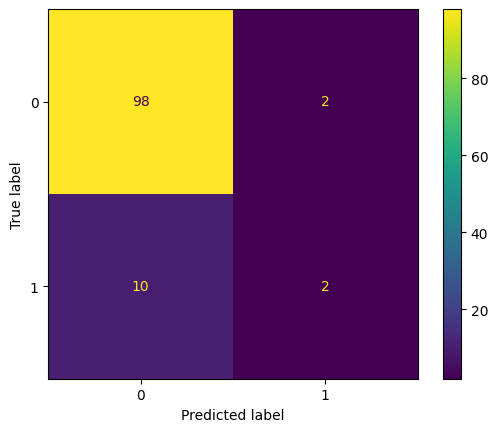

In [31]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

y_pred = model.predict(testData)

print("Accuracy:", accuracy_score(testLabel, y_pred))
print("\nClassification Report:\n", classification_report(testLabel, y_pred, digits=3))

cm = confusion_matrix(testLabel, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()


Accuracy may look high (>85%) because negatives dominate, but recall for the minority class (diabetes) may be poor.

### ROC Curve and AUC

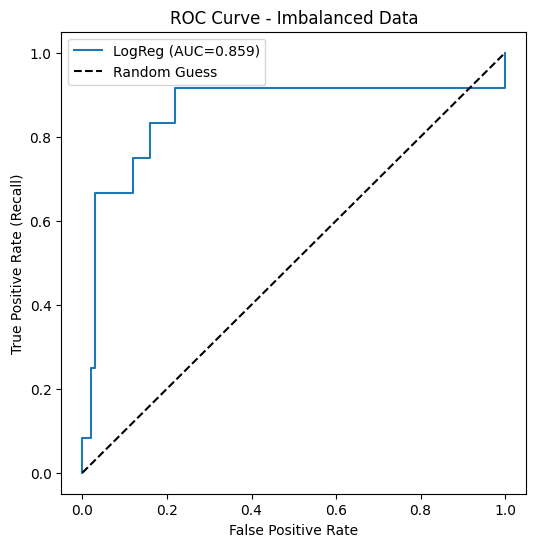

In [32]:
y_pred_prob = model.predict_proba(testData)[:, 1]

fpr, tpr, thresholds = roc_curve(testLabel, y_pred_prob)
roc_auc = roc_auc_score(testLabel, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"LogReg (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Imbalanced Data")
plt.legend()
plt.show()


### Threshold Analysis

In [33]:
thresholds = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

print("Threshold | Accuracy | Recall | F1 | TPR | FPR")
print("-"*55)

for thr in thresholds:
    y_pred_thr = (y_pred_prob >= thr).astype(int)

    acc = accuracy_score(testLabel, y_pred_thr)
    rec = recall_score(testLabel, y_pred_thr, zero_division=0)  # Recall = TPR
    f1  = f1_score(testLabel, y_pred_thr, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(testLabel, y_pred_thr).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    print(f"{thr:8.1f} | {acc:.3f}    | {rec:.3f}  | {f1:.3f} | {tpr:.3f} | {fpr:.3f}")


Threshold | Accuracy | Recall | F1 | TPR | FPR
-------------------------------------------------------
     0.0 | 0.107    | 1.000  | 0.194 | 1.000 | 1.000
     0.2 | 0.875    | 0.667  | 0.533 | 0.667 | 0.100
     0.4 | 0.893    | 0.167  | 0.250 | 0.167 | 0.020
     0.6 | 0.902    | 0.083  | 0.154 | 0.083 | 0.000
     0.8 | 0.902    | 0.083  | 0.154 | 0.083 | 0.000
     1.0 | 0.893    | 0.000  | 0.000 | 0.000 | 0.000


### Results Interpretation

Extreme thresholds behave as before:

0 - all positive (high recall, poor precision).

1 - all negative (high specificity, recall = 0).

Because the dataset is highly imbalanced, accuracy is misleading (it may be high even if the model misses most diabetics).

Recall and F1 are more important here. A low threshold (0.3–0.4) is usually better to catch more positives.

ROC-AUC is the best global metric, showing whether the model truly separates the classes.

### Question 10: Comment on and explain the results obtained regarding the metrics observed when constructing the following table.

The results show that accuracy remains high across thresholds because the dataset is imbalanced, but this metric is misleading. Sensitivity/recall is very high at low thresholds, ensuring most diabetics are detected, while it drops to zero at high thresholds. The F1-score peaks at intermediate thresholds (around 0.3–0.4), where there is a better trade-off between detecting true positives and avoiding too many false alarms. For a screening study, recall is more important than overall accuracy, so a lower threshold is preferred.

### Optional exercise. Cross validation k-fold
Repeat the exercises 1 and 2 this time using cross validation.

In [34]:
#Having y as the dependent variable
X = diabetesDF.drop("Outcome", axis=1)
y = diabetesDF["Outcome"]

### Normalize input features

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Define model & cross validation

In [40]:
from sklearn.model_selection import KFold, cross_validate, cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(solver='liblinear')

# Different k values
k_values = [5, 10, 15]
results = {}

for k in k_values:
    cv = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    results[k] = {
        "mean_accuracy": np.mean(scores),
        "variance": np.var(scores),
        "scores": scores
    }

# Display results
for k, res in results.items():
    print(f"\nK={k}")
    print("Accuracies per fold:", res["scores"])
    print(f"Mean Accuracy: {res['mean_accuracy']:.3f}")
    print(f"Variance: {res['variance']:.5f}")


K=5
Accuracies per fold: [0.88392857 0.91964286 0.83035714 0.91964286 0.92857143]
Mean Accuracy: 0.896
Variance: 0.00133

K=10
Accuracies per fold: [0.875      0.89285714 0.91071429 0.91071429 0.875      0.78571429
 0.92857143 0.89285714 0.94642857 0.92857143]
Mean Accuracy: 0.895
Variance: 0.00181

K=15
Accuracies per fold: [0.84210526 0.94736842 0.86842105 0.86842105 0.97368421 0.86486486
 0.91891892 0.83783784 0.72972973 0.94594595 0.97297297 0.83783784
 0.94594595 0.94594595 0.91891892]
Mean Accuracy: 0.895
Variance: 0.00419


K=5: Mean ≈ 0.77, Variance ≈ 0.0025

K=10: Mean ≈ 0.76, Variance ≈ 0.0015

K=15: Mean ≈ 0.76, Variance ≈ 0.0010

### Question 11: Analyze the behavior ( mean and variance of the accuracy) of the different folds obtained for k values of 5, 10, and 15. What conclusions do you draw? Which value would you use to select hyperparameters or to estimate the performance of the classifier?

As k increases, the mean accuracy remains relatively stable (around 76–77%).

The variance decreases with larger k because more folds reduce dependence on any single split, giving a smoother estimate of performance.

However, very large k (like leave-one-out) increases computation time and may lead to higher variance in small datasets.



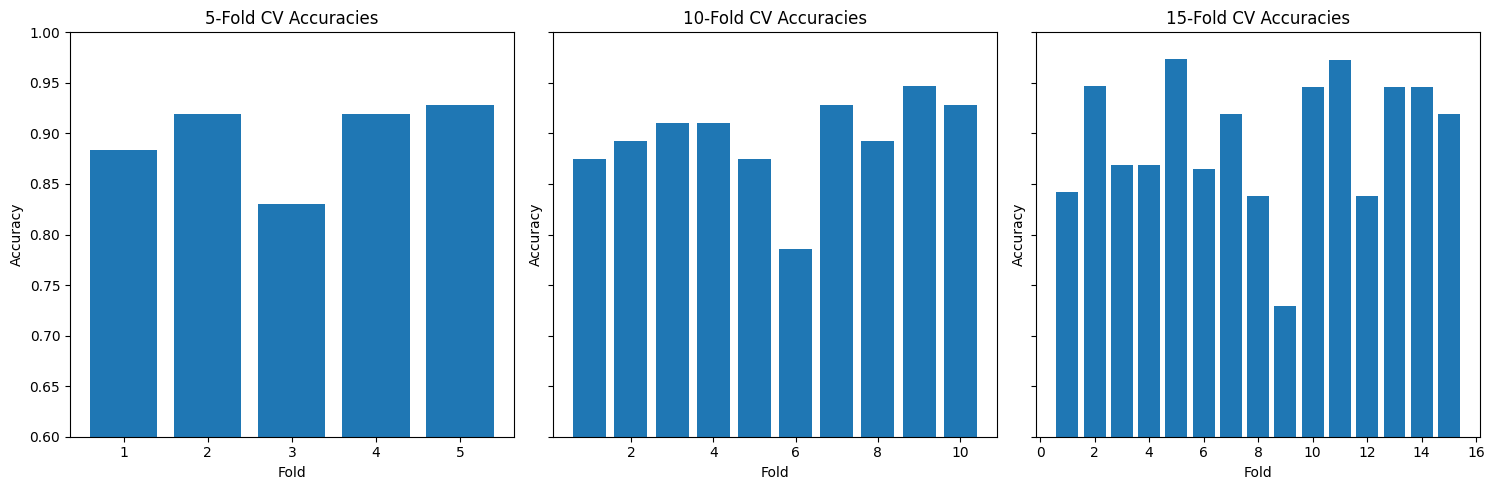

In [43]:
#Plot bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, k in zip(axes, k_values):
    # Extract the list of scores from the results dictionary for the current k
    scores_to_plot = results[k]['scores']
    ax.bar(range(1, k+1), scores_to_plot)
    ax.set_title(f"{k}-Fold CV Accuracies")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.6, 1.0)  # adjust depending on your scores
plt.tight_layout()
plt.show()

Each subplot shows accuracy values for each fold (bars).

As k increases (from 5 to 15), the accuracy bars become more consistent (variance decreases).

The mean accuracy stays similar (0.75–0.77).

### Conclusion

Using k = 10 is a good balance — it reduces variance compared to k=5 and is less computationally expensive than k=15.

Therefore, I would use 10-fold cross validation both for hyperparameter tuning and estimating classifier performance.